In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

import joblib


In [2]:
rfm = pd.read_csv("../data/rfm_raw.csv")
segments = pd.read_csv("../data/customer_segments.csv")

# Merge RFM and segment info
df = rfm.merge(
    segments[["CustomerID", "Segment"]],
    on="CustomerID",
    how="left"
)

df.head()


,CustomerID,Recency,Frequency,Monetary,Segment
0,12346.0,326,1,77183.60,New Customers
1,12347.0,2,7,4310.00,At-Risk Customers
2,12348.0,75,4,1797.24,New Customers
3,12349.0,19,1,1757.55,Loyal High-Value
4,12350.0,310,1,334.40,Low-Value Customers


In [3]:
df["CLV"] = df["Monetary"] * df["Frequency"]

df[["CustomerID", "Recency", "Frequency", "Monetary", "CLV"]].head()


,CustomerID,Recency,Frequency,Monetary,CLV
0,12346.0,326,1,77183.60,77183.60
1,12347.0,2,7,4310.00,30170.00
2,12348.0,75,4,1797.24,7188.96
3,12349.0,19,1,1757.55,1757.55
4,12350.0,310,1,334.40,334.40


In [4]:
df = pd.get_dummies(df, columns=["Segment"], drop_first=True)
df.head()


,CustomerID,Recency,Frequency,Monetary,CLV,Segment_Low-Value Customers,Segment_Loyal High-Value,Segment_New Customers
0,12346.0,326,1,77183.60,77183.60,False,False,True
1,12347.0,2,7,4310.00,30170.00,False,False,False
2,12348.0,75,4,1797.24,7188.96,False,False,True
3,12349.0,19,1,1757.55,1757.55,False,True,False
4,12350.0,310,1,334.40,334.40,True,False,False


In [5]:
X = df.drop(columns=["CustomerID", "CLV"])
y = df["CLV"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (4339, 6)
Target shape: (4339,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [8]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.2f}")
print(f"Random Forest R2: {r2_rf:.2f}")


Random Forest RMSE: 121921.03
Random Forest R2: 0.95


In [9]:
xgb = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)


In [10]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb:.2f}")
print(f"XGBoost R2: {r2_xgb:.2f}")


XGBoost RMSE: 932793.41
XGBoost R2: -1.75


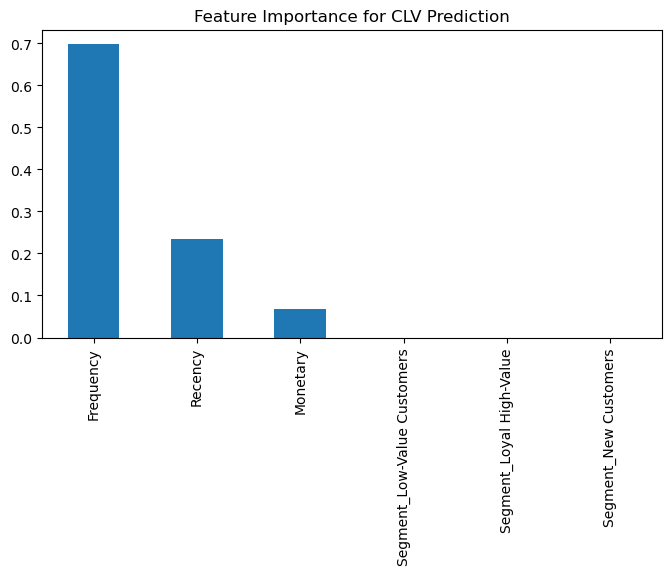

In [11]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp.sort_values(ascending=False).plot(kind="bar", figsize=(8,4))
plt.title("Feature Importance for CLV Prediction")
plt.show()


In [12]:
joblib.dump(xgb, "../models/clv_model.pkl")
print("✅ CLV model saved successfully")


✅ CLV model saved successfully


In [13]:
df["Predicted_CLV"] = xgb.predict(X)

df[["CustomerID", "Predicted_CLV"]].to_csv("../data/predicted_clv.csv", index=False)
print("✅ Predicted CLV saved for frontend/dashboard")


✅ Predicted CLV saved for frontend/dashboard
